## BST UTC+1 2018 10:28

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
files = {
    "df_inj1": "../data/PNR/raw/PNR-1z_injection_rates.txt",
    "df_inj2": "../data/PNR/raw/PNR-2_injection_rates.txt",
    "df_cat1": "../data/PNR/raw/PNR-1z_microseismicity_catalogue.txt",
    "df_cat2": "../data/PNR/raw/PNR-2_microseismicity_catalogue.txt",
}

_read = lambda p: pd.read_csv(p, sep=r"\s+", skiprows=[0, 2], header=0)
for name, path in files.items():
    globals()[name] = _read(path)

## Add timestamp

In [2]:
def add_datetime_column(df, out_col='ts', set_index=False,delete_original=False):
    candidates = {
        'year': ('year', 'Year', 'YEAR'),
        'month': ('month', 'Month', 'MONTH'),
        'day': ('day', 'Day', 'DAY', 'Day '),
        'hour': ('hr', 'hour', 'Hour', 'HR'),
        'minute': ('min', 'minute', 'Minute', 'MIN'),
        'second': ('sec', 'second', 'Second', 'SEC')
    }

    def _pick(col_names):
        for c in col_names:
            if c in df.columns:
                return c
        raise KeyError(f"None of {col_names} found in dataframe columns")

    picked = {k: _pick(v) for k, v in candidates.items()}

    # prepare subset and rename to pandas-expected names
    subset = df[[picked['year'], picked['month'], picked['day'],
                 picked['hour'], picked['minute'], picked['second']]].rename(
        columns={
            picked['year']: 'year',
            picked['month']: 'month',
            picked['day']: 'day',
            picked['hour']: 'hour',
            picked['minute']: 'minute',
            picked['second']: 'second'
        }
    )
    df[out_col] = pd.to_datetime(subset)
    if set_index:
        df.set_index(out_col, inplace=True)
    if delete_original:
        df.drop(columns=list(picked.values()), inplace=True)
    return df

In [3]:
for name in ("df_inj1", "df_inj2", "df_cat1", "df_cat2"):
    globals()[name] = add_datetime_column(globals()[name], out_col="ts", set_index=True, delete_original=True)

In [5]:
def normalize_catalog(df, index_name='ts', lon='Lon', lat='Lat', mag='Mag', depth='Z(km)'):
    rename_map = {}
    if lon in df.columns:
        rename_map[lon] = 'Longitude'
    if lat in df.columns:
        rename_map[lat] = 'Latitude'
    if mag in df.columns:
        rename_map[mag] = 'Magnitude'
    if depth in df.columns:
        rename_map[depth] = 'Depth'

    if rename_map:
        df = df.rename(columns=rename_map)

    desired = [index_name, 'Latitude', 'Longitude', 'Magnitude', 'Depth']
    existing = [c for c in desired if c in df.columns]
    return df[existing]

df_cat1 = normalize_catalog(df_cat1)
df_cat2 = normalize_catalog(df_cat2)

## Align the index

In [5]:
df_inj1['dt'] = df_inj1.index.to_series().diff().dt.total_seconds()
print(f"dt distribution:\n{df_inj1['dt'].value_counts().sort_index()}")
min_dt_idx = df_inj1['dt'].idxmin()
min_dt_value = df_inj1.loc[min_dt_idx, "dt"]
print(f"Minimum dt: {min_dt_value} seconds at index {min_dt_idx}")
time_delta = pd.Timedelta(seconds=5)
start_time = min_dt_idx - time_delta
end_time = min_dt_idx + time_delta
mask = (df_inj1.index >= start_time) & (df_inj1.index <= end_time)
df_inj1_window = df_inj1.loc[mask]
print(f"Data around minimum dt:\n{df_inj1_window}")
start_time = pd.Timestamp("2018-10-27 23:59:00")
end_time = pd.Timestamp("2018-10-29 00:00:00")
mask = (df_inj1.index >= start_time) & (df_inj1.index <= end_time)
df_inj1_window = df_inj1.loc[mask]
print(f"Data from 2018-10-27 23:00:00 to 2018-10-29 10:00:00:\n{df_inj1_window}")


dt distribution:
dt
-63.0               1
 0.0              667
 1.0          1962688
 2.0              361
 3.0                1
 233.0              1
 280.0              1
 338.0              1
 524.0              1
 720.0              1
 763.0              1
 807.0              1
 872.0              1
 926.0              1
 1376.0             1
 1407.0             1
 1635.0             1
 2265.0             1
 2468.0             1
 2548.0             1
 4286.0             1
 9066.0             1
 10854.0            1
 86796.0            1
 87747.0            1
 113837.0           1
 118171.0           1
 3051353.0          1
Name: count, dtype: int64
Minimum dt: ts
2018-12-08 10:10:00     1.0
2018-12-08 10:10:00   -63.0
Name: dt, dtype: float64 seconds at index 2018-12-08 10:10:00
Data around minimum dt:
                     injection_rate(m^3/min)    dt
ts                                                
2018-12-08 10:09:55                -0.001007   1.0
2018-12-08 10:09:56         

## Convert BST to UTC

In [6]:
import pandas as pd

localized_index = df_inj1.index.tz_localize(
    'Europe/London', 
    ambiguous='infer'
)
utc_index = localized_index.tz_convert('UTC')
df_inj1.index = utc_index
# df_inj1.index = df_inj1.index.tz_localize(None)
print(df_inj1.index.dtype) 
print(df_inj1.head())
print("DataFrame df_inj1 after timezone conversion:")

datetime64[ns, UTC]
                           injection_rate(m^3/min)   dt
ts                                                     
2018-10-15 08:56:31+00:00                      0.0  NaN
2018-10-15 08:56:32+00:00                      0.0  1.0
2018-10-15 08:56:33+00:00                      0.0  1.0
2018-10-15 08:56:34+00:00                      0.0  1.0
2018-10-15 08:56:35+00:00                      0.0  1.0
DataFrame df_inj1 after timezone conversion:


In [7]:
df_inj1.index = df_inj1.index.tz_localize(None)

## Sort and remove duplicates

In [8]:
df_inj1 = (df_inj1.sort_index().drop_duplicates())
df_inj2 = (df_inj2.sort_index().drop_duplicates())
df_cat1 = (df_cat1.sort_index().drop_duplicates())
df_cat2 = (df_cat2.sort_index().drop_duplicates())

In [9]:
def summarize_index_duplicates(df, n=10, sort_index=False):
    df2 = df.sort_index() if sort_index else df
    is_mono = df2.index.is_monotonic_increasing
    has_dup = df2.index.has_duplicates
    dup_times = df2.index[df2.index.duplicated()]
    df_dup  = df2[df2.index.duplicated(keep=False)]
    equal_flag = (
        df_dup
        .groupby(level=0)
        .apply(lambda x: x.nunique().eq(1).all())
    )
    ratio_by_time = equal_flag.mean()
    bad_times = equal_flag[equal_flag==False].index
    df.loc[bad_times]
    print(f"Is index monotonic increasing: {is_mono}")
    print(f"Does index have duplicates: {has_dup}")
    print(f"Number of duplicate times: {len(dup_times)}")
    print(f"Ratio of duplicate times with equal values: {ratio_by_time}")
    print(f"Preview of duplicate times with unequal values: {dup_times[:n]}")
    print(f"Preview of rows with unequal values:")
    print(df.loc[bad_times])
    return {
        "df": df2,
        "is_monotonic": is_mono,
        "has_duplicates": has_dup,
        "dup_times": dup_times,
        "dup_preview": dup_times[:n],
        "equal_flag": equal_flag,
        "ratio_by_time": ratio_by_time,
        "bad_times": bad_times,
    }

res = summarize_index_duplicates(df_inj1)


Is index monotonic increasing: True
Does index have duplicates: True
Number of duplicate times: 111
Ratio of duplicate times with equal values: 0.0
Preview of duplicate times with unequal values: DatetimeIndex(['2018-10-17 10:10:25', '2018-10-17 15:24:56',
               '2018-10-17 15:25:08', '2018-10-17 15:25:26',
               '2018-10-17 15:25:30', '2018-10-17 15:25:34',
               '2018-10-17 15:25:36', '2018-10-17 15:26:04',
               '2018-10-17 15:26:06', '2018-10-17 15:26:13'],
              dtype='datetime64[ns]', name='ts', freq=None)
Preview of rows with unequal values:
                     injection_rate(m^3/min)   dt
ts                                               
2018-10-17 10:10:25                 0.120670  2.0
2018-10-17 10:10:25                 0.120670  0.0
2018-10-17 15:24:56                 2.093490  0.0
2018-10-17 15:24:56                 2.093490  1.0
2018-10-17 15:25:08                 2.093720  1.0
...                                      ...  ...
2

In [10]:
df_inj1 = (df_inj1.sort_index().groupby(level=0).mean())
df_inj2 = (df_inj2.sort_index().groupby(level=0).mean())

## Find missing values

In [11]:
import pandas as pd
df_inj1.index = pd.to_datetime(df_inj1.index)
diff = df_inj1.index.to_series().diff()
gaps_greater_than_1min = diff[diff > pd.Timedelta(minutes=1)]
print(gaps_greater_than_1min.head())
df_inj1.index = pd.to_datetime(df_inj1.index)
diff = df_inj1.index.to_series().diff()
gaps_greater_than_1min = diff[diff > pd.Timedelta(minutes=1)]
print(gaps_greater_than_1min.head())
print("Total gaps > 1 minute:", len(gaps_greater_than_1min))

ts
2018-10-15 09:12:04   0 days 00:15:32
2018-10-15 09:14:18   0 days 00:01:02
2018-10-15 09:16:11   0 days 00:01:06
2018-10-15 09:23:15   0 days 00:06:33
2018-10-15 09:25:56   0 days 00:02:41
Name: ts, dtype: timedelta64[ns]
ts
2018-10-15 09:12:04   0 days 00:15:32
2018-10-15 09:14:18   0 days 00:01:02
2018-10-15 09:16:11   0 days 00:01:06
2018-10-15 09:23:15   0 days 00:06:33
2018-10-15 09:25:56   0 days 00:02:41
Name: ts, dtype: timedelta64[ns]
Total gaps > 1 minute: 522


In [12]:
gaps_greater_than_1min

ts
2018-10-15 09:12:04   0 days 00:15:32
2018-10-15 09:14:18   0 days 00:01:02
2018-10-15 09:16:11   0 days 00:01:06
2018-10-15 09:23:15   0 days 00:06:33
2018-10-15 09:25:56   0 days 00:02:41
                            ...      
2018-12-17 11:40:41   0 days 00:37:44
2018-12-17 12:17:55   0 days 00:37:10
2018-12-17 12:20:25   0 days 00:01:55
2018-12-17 12:49:27   0 days 00:29:00
2018-12-17 13:12:09   0 days 00:22:42
Name: ts, Length: 522, dtype: timedelta64[ns]

## Find outliers

In [13]:
df_inj1[df_inj1['injection_rate(m^3/min)'] > 50].index

DatetimeIndex(['2018-10-25 12:28:12', '2018-10-25 12:28:13',
               '2018-10-25 12:54:26', '2018-10-25 12:54:27',
               '2018-10-25 12:54:28', '2018-10-25 12:54:29',
               '2018-10-25 12:54:31', '2018-10-25 12:54:32',
               '2018-10-25 12:54:33', '2018-10-25 12:54:34',
               '2018-10-26 08:00:26', '2018-10-26 08:00:30',
               '2018-10-26 08:00:32'],
              dtype='datetime64[ns]', name='ts', freq=None)

## Downsampling

In [14]:
df_inj1_m = df_inj1.resample('min').mean()
df_inj1_m.rename(columns={'injection_rate(m^3/min)': 'IR_h'}, inplace=True)  
df_inj2_m = df_inj2.resample('min').sum()
df_inj2_m.rename(columns={'injection_rate(m^3/s)': 'IR_h'}, inplace=True)

## Fill in missing values

In [15]:
import pandas as pd
df_inj1_m.index = pd.to_datetime(df_inj1_m.index)
new_index = pd.date_range(start=df_inj1_m.index.min(), end='2018-12-18 12:31:00', freq='min')
df_inj1_m = df_inj1_m.reindex(new_index, fill_value=0)
df_inj1_m['IR_h'] = df_inj1_m['IR_h'].fillna(0)
df_inj1_m.index.name = 'ts'
print(df_inj1_m.isna().sum())

IR_h        0
dt      89114
dtype: int64


## Replace outliers with 0

In [16]:
mask1 = df_inj1_m['IR_h'] > 10
print(df_inj1_m[mask1])
df_inj1_m.loc[mask1, 'IR_h'] = 0
mask2 = df_inj1_m['IR_h'] < 0
print(df_inj1_m[mask2])
df_inj1_m.loc[mask2, 'IR_h'] = 0


                           IR_h   dt
ts                                  
2018-10-25 12:28:00  231.150500  1.0
2018-10-25 12:54:00   96.803988  1.0
2018-10-26 08:00:00   31.287539  1.0
                         IR_h        dt
ts                                     
2018-10-19 10:28:00 -0.000110       1.0
2018-10-19 10:29:00 -0.000450       1.0
2018-10-19 10:30:00 -0.256747       1.0
2018-10-19 10:31:00 -0.256690       1.0
2018-10-19 10:35:00 -0.256660       1.0
2018-10-19 10:46:00 -0.029398       1.0
2018-10-19 10:47:00 -0.000420       1.0
2018-10-19 10:48:00 -0.000300       1.0
2018-10-19 10:50:00 -0.273120       1.0
2018-10-29 10:25:00 -0.001007       2.0
2018-10-29 11:48:00 -0.000092       1.0
2018-10-29 16:22:00 -0.001923       1.0
2018-10-30 03:57:00 -0.001465       2.0
2018-10-30 04:12:00 -0.001465       0.0
2018-10-30 04:16:00 -0.001007       0.0
2018-12-10 07:37:00 -0.001007  113837.0
2018-12-10 20:02:00 -0.001465       3.0
2018-12-13 07:31:00 -0.001465   86796.0
2018-12-14 04:2

<Axes: title={'center': 'PNR-1z Injection Rate After Preprocessing'}, xlabel='Time', ylabel='Injection Rate (m^3/min)'>

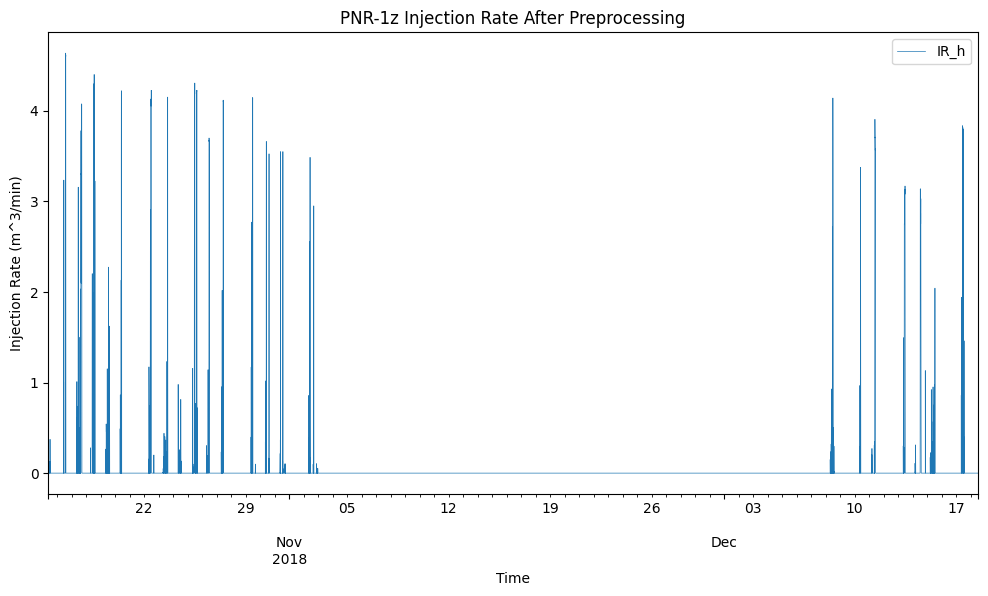

In [17]:
df_inj1_m.plot(y='IR_h', title='PNR-1z Injection Rate After Preprocessing', ylabel='Injection Rate (m^3/min)', xlabel='Time', figsize=(12,6),linewidth=0.5)

## Save data

In [18]:
df_cat1.to_csv("../data/PNR/raw/PNR_1z_catalog.csv")
df_cat2.to_csv("../data/PNR/raw/PNR_2z_catalog.csv")

In [19]:
df_inj1_m.to_csv("../data/PNR/raw/PNR_1z_injection_rate_per_min.csv")

In [20]:
df_cat1,df_inj1

(                     Latitude  Longitude  Magnitude    Depth
 ts                                                          
 2018-10-15 13:24:02   53.7858   -2.97509     -1.828 -2.28428
 2018-10-15 16:32:00   53.7860   -2.97186     -2.169 -2.27763
 2018-10-15 18:49:04   53.7876   -2.96736     -2.290 -2.16380
 2018-10-16 01:06:52   53.7879   -2.97051     -1.864 -2.28625
 2018-10-16 10:54:18   53.7859   -2.97539     -1.563 -2.30682
 ...                       ...        ...        ...      ...
 2018-12-18 12:22:40   53.7866   -2.96574     -2.223 -2.40834
 2018-12-18 12:22:42   53.7876   -2.96454     -1.895 -2.21559
 2018-12-18 12:25:00   53.7879   -2.96438     -2.572 -2.23871
 2018-12-18 12:30:13   53.7879   -2.96373     -2.514 -2.23791
 2018-12-18 12:30:56   53.7876   -2.96448     -1.805 -2.21443
 
 [38246 rows x 4 columns],
                      injection_rate(m^3/min)   dt
 ts                                               
 2018-10-15 08:56:31                  0.00000  NaN
 2018-10-15 

## Find Peak

In [89]:
from scipy.signal import find_peaks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def detect_peaks_in_series(df, col='IR_h', prominence=0.1, distance=5, wlen=None, plot_ax=None, marker_kwargs=None,**args):
    """
    检测时间序列中的峰值，并返回峰值、以及对应峰的起始和结束时间。

    Args:
        df (pd.DataFrame): 包含时间序列数据的 DataFrame。
        col (str): 要检测峰值的列名。
        prominence (float): 峰的显著性要求。
        distance (int): 两个峰之间的最小水平距离（样本点数）。
        wlen (int, optional): 用于计算基线的窗口长度。如果为 None，默认为序列长度。
        plot_ax (matplotlib.axes.Axes, optional): 用于绘图的 Matplotlib Axes 对象。
        marker_kwargs (dict, optional): 峰值标记的绘图参数。

    Returns:
        dict: 包含峰值信息和峰的起始/结束时间的字典。
    """
    s = df[col].to_numpy()
    if wlen is None:
        wlen = len(s)
    idx, props = find_peaks(
        s, 
        prominence=prominence, 
        distance=distance, 
        wlen=wlen,  
        **args
    )
    
    t_peaks = df.index[idx]
    v_peaks = df[col].iloc[idx]
    
    left_bases = props.get('left_bases', np.array([]))
    right_bases = props.get('right_bases', np.array([]))

    t_left_base = df.index[left_bases]
    t_right_base = df.index[right_bases]

    if plot_ax is not None:
        mk = {'color': 'k', 'marker': 'x', 'linestyle': 'None', 'markersize': 6}
        if marker_kwargs:
            mk.update(marker_kwargs)
        
        plot_ax.plot(t_peaks, v_peaks, **mk)
        
        if left_bases.size > 0:
            plot_ax.plot(t_left_base, df[col].iloc[left_bases], 'v', color='blue', markersize=4, label='Left Base')
            plot_ax.plot(t_right_base, df[col].iloc[right_bases], '^', color='red', markersize=4, label='Right Base')

    return {
        'idx': idx, 
        'props': props, 
        't_peaks': t_peaks, 
        'v_peaks': v_peaks,
        't_left_base': t_left_base,     
        't_right_base': t_right_base    # 峰的结束时间
    }
cfg = {'height': 1.5}
peak_info_inj = detect_peaks_in_series(df_inj1_m, col='IR_h', prominence=0.5, distance=5, **cfg)
eq_cnt = df_cat1.resample(dt).size().to_frame("eq_count")
peak_info_eq = detect_peaks_in_series(eq_cnt, col='eq_count', prominence=1, distance=5)    
print(f"peak_inj_info: {peak_info_inj['t_peaks']}")

peak_inj_info: DatetimeIndex(['2018-10-16 10:52:00', '2018-10-16 13:52:00',
               '2018-10-17 10:44:00', '2018-10-17 13:31:00',
               '2018-10-17 14:26:00', '2018-10-17 15:19:00',
               '2018-10-17 16:19:00', '2018-10-18 09:57:00',
               '2018-10-18 11:24:00', '2018-10-18 12:47:00',
               '2018-10-18 12:54:00', '2018-10-18 13:06:00',
               '2018-10-18 13:42:00', '2018-10-18 14:20:00',
               '2018-10-19 12:48:00', '2018-10-19 14:36:00',
               '2018-10-20 09:45:00', '2018-10-20 09:50:00',
               '2018-10-20 09:56:00', '2018-10-20 10:01:00',
               '2018-10-20 10:06:00', '2018-10-20 10:34:00',
               '2018-10-20 10:39:00', '2018-10-22 10:10:00',
               '2018-10-22 11:39:00', '2018-10-23 14:45:00',
               '2018-10-25 11:40:00', '2018-10-25 14:44:00',
               '2018-10-25 15:02:00', '2018-10-26 11:19:00',
               '2018-10-27 09:00:00', '2018-10-27 10:44:00',
         

In [98]:
peak_info_inj['t_left_base'][:10], peak_info_inj['t_right_base'][:10]

(DatetimeIndex(['2018-10-16 10:47:00', '2018-10-16 13:27:00',
                '2018-10-17 10:40:00', '2018-10-17 13:30:00',
                '2018-10-17 14:23:00', '2018-10-17 15:06:00',
                '2018-10-17 15:06:00', '2018-10-18 09:54:00',
                '2018-10-18 11:21:00', '2018-10-18 12:42:00'],
               dtype='datetime64[ns]', name='ts', freq=None),
 DatetimeIndex(['2018-10-16 10:57:00', '2018-10-16 14:07:00',
                '2018-10-17 10:48:00', '2018-10-17 13:32:00',
                '2018-10-17 14:27:00', '2018-10-17 15:36:00',
                '2018-10-17 16:36:00', '2018-10-18 10:01:00',
                '2018-10-18 11:25:00', '2018-10-18 12:48:00'],
               dtype='datetime64[ns]', name='ts', freq=None))

In [85]:
len(peak_info_inj['t_peaks'])

58

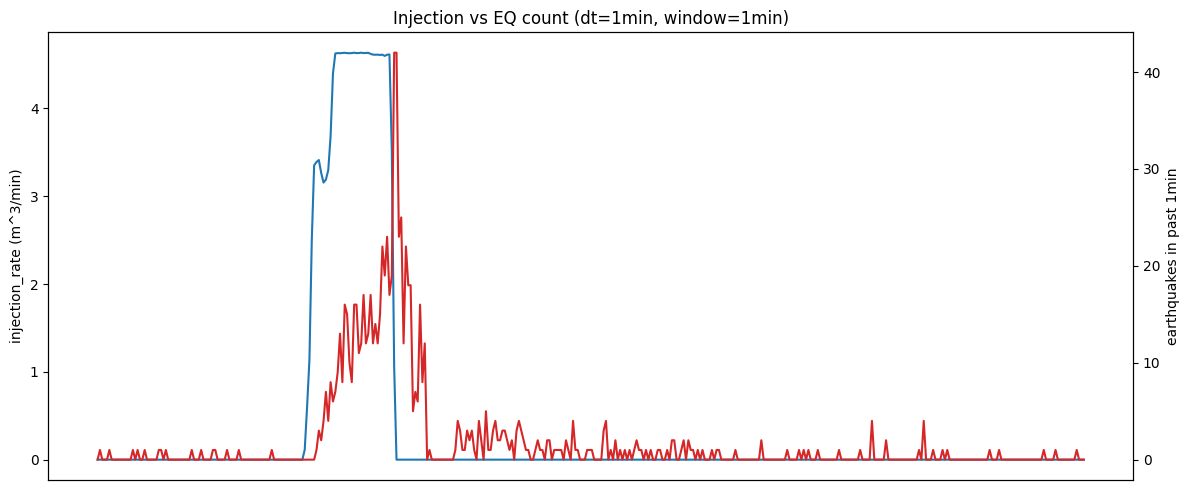

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
start = "2018-10-16 12:00:00"
end   = "2018-10-16 18:59:59"
# start = "2018-10-18 12:40:00"
# end   = "2018-10-18 13:48:00"
offset = pd.Timedelta(hours=1)

dt = "1min"         # ：比如 '1min','5min','10min','1H'
win = "1min"           # 时间窗：比如 '1H','6H','1D'（用于“窗内地震数量”）
# =========================
inj = df_inj1_m.loc[start:end].copy()     # 注水：一列 injection_rate(m^3/min)
eq  = df_cat1.loc[start:end].copy()     # 地震：多列，index 为地震发生时刻

inj_dt = inj.resample(dt).mean()
eq_cnt_dt = eq.resample(dt).size().to_frame("eq_count")
# eq_cnt_win = eq_cnt_dt.rolling(win).sum().rename(columns={"eq_count": f"eq_count_{win}"})
df_plot = inj_dt.join(eq_cnt_dt, how="outer").fillna(0)
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_plot.index, df_plot[inj_dt.columns[0]], color='tab:blue')
ax1.set_ylabel("injection_rate (m^3/min)")

ax2 = ax1.twinx()
ax2.plot(df_plot.index, df_plot["eq_count"], color='tab:red')
ax2.set_ylabel(f"earthquakes in past {win}")

ax1.set_title(f"Injection vs EQ count (dt={dt}, window={win})")
plt.tight_layout()
plt.show()


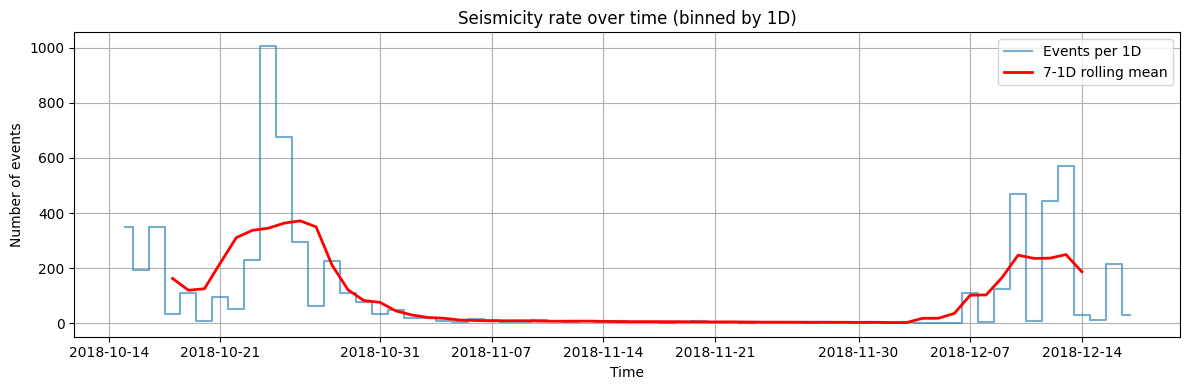

In [25]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
df_cat1_filtered = df_cat1[df_cat1['Magnitude'] >= -1.5]
event_counts = df_cat1_filtered.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()

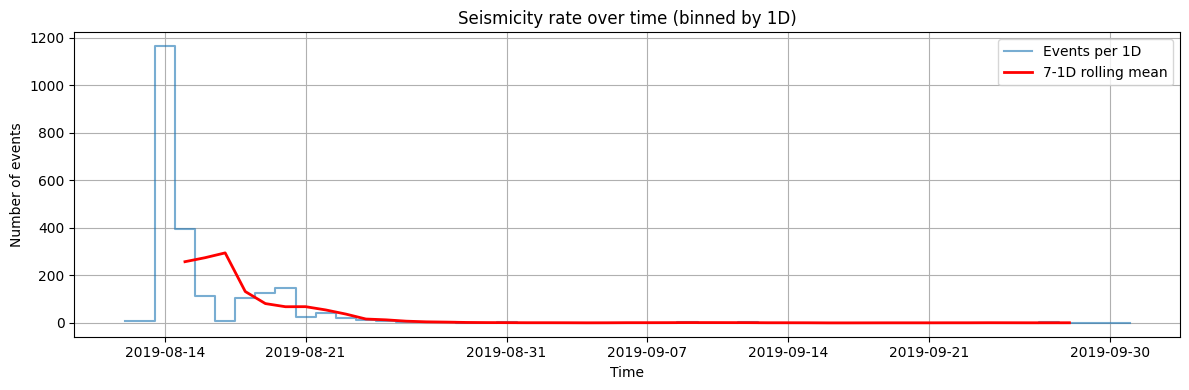

In [26]:
# Try to specify common CJK fonts to avoid missing-glyph warnings (matplotlib picks the first available)
plt.figure(figsize=(12,4))
freq = '1D'  # 1 day
window = 7  # 7 periods
event_counts = df_cat2.resample(freq).size()
smoothed = event_counts.rolling(window=window, center=True).mean()
plt.plot(event_counts.index, event_counts, drawstyle='steps-mid', alpha=0.6, label=f'Events per {freq}')
plt.plot(smoothed.index, smoothed, color='red', lw=2, label=f'{window}-{freq} rolling mean')
plt.xlabel('Time')
plt.ylabel('Number of events')
plt.title(f'Seismicity rate over time (binned by {freq})')
plt.legend()
plt.grid(True)
plt.tight_layout()


<Axes: >

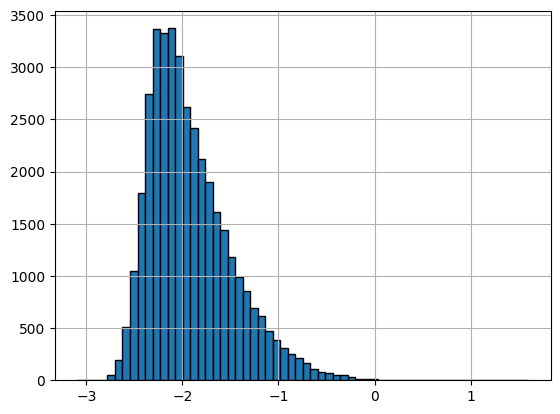

In [27]:
df_cat1['Magnitude'].hist(bins=60, edgecolor='black')

In [28]:
len(df_cat2[df_cat2['Magnitude']>-2])

2021

In [31]:
df_inj1_h= df_inj1.resample('h').mean()
df_inj2_h= df_inj2.resample('h').sum()/60
df_inj1_h.rename(columns={'injection_rate(m^3/min)':'IR_h'}, inplace=True)
df_inj2_h.rename(columns={'injection_rate(m^3/s)':'IR_h'}, inplace=True)


<Axes: xlabel='ts'>

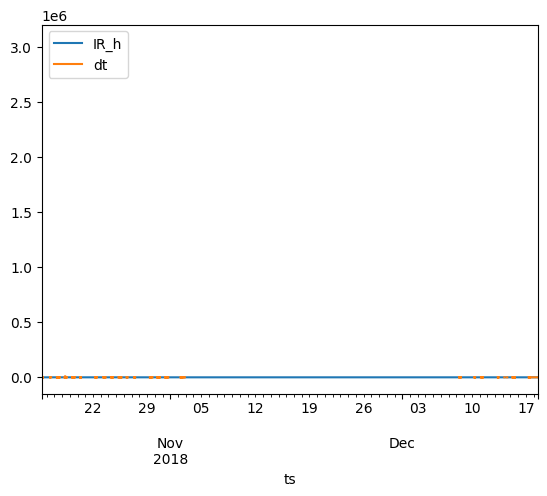

In [32]:
df_inj1_m.plot()

In [33]:
event_counts_min = df_cat1.resample('T').size()
event_counts_min.head()

/root/autodl-tmp/tmp/ipykernel_2693/2704100517.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  event_counts_min = df_cat1.resample('T').size()


ts
2018-10-15 13:24:00    1
2018-10-15 13:25:00    0
2018-10-15 13:26:00    0
2018-10-15 13:27:00    0
2018-10-15 13:28:00    0
Freq: min, dtype: int64

<Axes: xlabel='ts'>

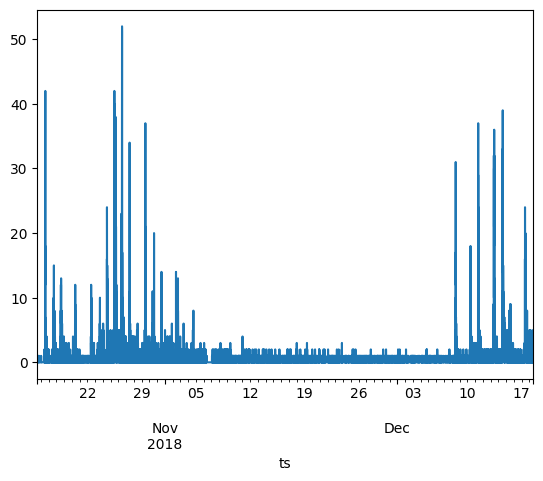

In [34]:
event_counts_min.plot()

In [35]:
# 找到最后一个注入量非0的时间（以 df_inj2_h 为例）
nonzero = df_inj2_h[df_inj2_h.iloc[:, 0] != 0]
if nonzero.empty:
    last_nonzero_date = None
    print("没有非0注入量的记录")
else:
    last_nonzero_date = nonzero.index.max()
    print(last_nonzero_date)

2019-08-23 15:00:00


In [36]:
df_inj2_h

,IR_h
ts,
2019-08-13 16:00:00,0.000000
2019-08-13 17:00:00,0.026646
2019-08-13 18:00:00,0.000000
2019-08-13 19:00:00,0.000000
2019-08-13 20:00:00,0.000000
...,...
2019-08-23 11:00:00,0.208072
2019-08-23 12:00:00,0.001805
2019-08-23 13:00:00,0.444930


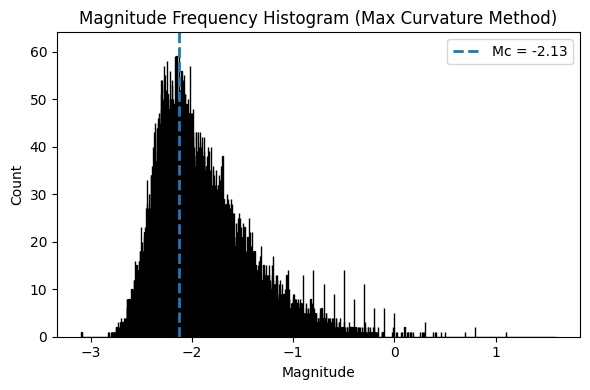

Estimated Mc = -2.13


In [37]:
from  src.data.preprocessing import estimate_mc_max_curvature
mags = df_cat1["Magnitude"].values
mc, bin_centers, counts = estimate_mc_max_curvature(mags, bin_width=0.001, plot=True)
print(f"Estimated Mc = {mc:.2f}")

In [38]:
df = pd.read_csv("../data/PNR/raw/PNR_1z_catalog.csv", parse_dates=['ts'])
start_ts = pd.Timestamp("2018-10-15 12:00:00")
arrival_times = ((df['ts'] - start_ts) / pd.Timedelta("1h")).values

In [39]:
df['ts']

0       2018-10-15 13:24:02
1       2018-10-15 16:32:00
2       2018-10-15 18:49:04
3       2018-10-16 01:06:52
4       2018-10-16 10:54:18
                ...        
38241   2018-12-18 12:22:40
38242   2018-12-18 12:22:42
38243   2018-12-18 12:25:00
38244   2018-12-18 12:30:13
38245   2018-12-18 12:30:56
Name: ts, Length: 38246, dtype: datetime64[ns]

In [40]:
arrival_times

array([1.40055556e+00, 4.53333333e+00, 6.81777778e+00, ...,
       1.53641667e+03, 1.53650361e+03, 1.53651556e+03])